In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/README.md
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/data.csv
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_52.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_10.tif
/kaggle/input/datasets/ma

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import glob
from torch.utils.data import Dataset
import numpy as np

In [4]:


# Ye humara final, confirmed dataset path hai
DATASET_PATH = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation"

# Andar kya hai dekhte hain
for item in os.listdir(DATASET_PATH):
    print(item)

kaggle_3m
lgg-mri-segmentation


In [5]:

print("--- kaggle_3m ke andar ---")
print(os.listdir(os.path.join(DATASET_PATH, "kaggle_3m"))[:10])  # sirf pehle 10 items

print("\n--- lgg-mri-segmentation ke andar ---")
print(os.listdir(os.path.join(DATASET_PATH, "lgg-mri-segmentation"))[:10])

--- kaggle_3m ke andar ---
['TCGA_DU_7010_19860307', 'TCGA_DU_8162_19961029', 'TCGA_FG_A4MT_20020212', 'TCGA_FG_5964_20010511', 'TCGA_DU_A5TS_19970726', 'TCGA_HT_7692_19960724', 'TCGA_DU_5849_19950405', 'TCGA_FG_A60K_20040224', 'TCGA_HT_7475_19970918', 'TCGA_FG_6691_20020405']

--- lgg-mri-segmentation ke andar ---
['kaggle_3m']


In [6]:

DATASET_PATH = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

# Kitne patients hain total?
patients = os.listdir(DATASET_PATH)
print(f"Total patients: {len(patients)}")
print(f"Pehla patient: {patients[0]}")

Total patients: 112
Pehla patient: TCGA_DU_7010_19860307


In [7]:
# Pehle patient ka poora path banate hain
first_patient = "TCGA_DU_7010_19860307"
patient_folder = os.path.join(DATASET_PATH, first_patient)

# Is patient ke andar kya files hain?
files = os.listdir(patient_folder)
print(f"Total files: {len(files)}")
print("Pehli 10 files:")
for f in files[:10]:
    print(f)

Total files: 116
Pehli 10 files:
TCGA_DU_7010_19860307_45.tif
TCGA_DU_7010_19860307_56_mask.tif
TCGA_DU_7010_19860307_57.tif
TCGA_DU_7010_19860307_33.tif
TCGA_DU_7010_19860307_27.tif
TCGA_DU_7010_19860307_52.tif
TCGA_DU_7010_19860307_10.tif
TCGA_DU_7010_19860307_8_mask.tif
TCGA_DU_7010_19860307_34_mask.tif
TCGA_DU_7010_19860307_33_mask.tif


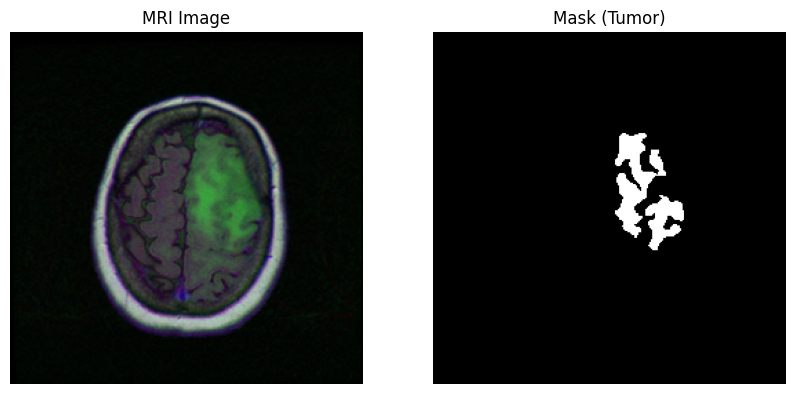

In [8]:
# Slice number 45 ki image aur uska mask kholte hain
image_path = os.path.join(patient_folder, "TCGA_DU_7010_19860307_45.tif")
mask_path = os.path.join(patient_folder, "TCGA_DU_7010_19860307_45_mask.tif")

image = Image.open(image_path)
mask = Image.open(mask_path)

# Dono ko side-by-side dikhate hain
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("MRI Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask (Tumor)")
axes[1].axis("off")

plt.show()

In [9]:
# Saari image files dhoondo (jo "_mask" nahi hain)
all_files = glob.glob(os.path.join(DATASET_PATH, "*", "*.tif"))
image_files = [f for f in all_files if "_mask" not in f]

print(f"Total images (bina mask ke): {len(image_files)}")
print("Example:", image_files[0])

Total images (bina mask ke): 3929
Example: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif


In [10]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class BrainMRIDataset(Dataset):
    def __init__(self, image_files):
        self.image_files = image_files
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Image ka path lo
        image_path = self.image_files[idx]
        
        # Mask ka path banao (image path se, sirf naam mein "_mask" jorh kar)
        mask_path = image_path.replace(".tif", "_mask.tif")
        
        # Dono load karo
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # "L" = grayscale
        
        # PIL image ko numpy array mein convert karo
        image = np.array(image)
        mask = np.array(mask)
        
        return image, mask

In [11]:
# Dataset object banao
dataset = BrainMRIDataset(image_files)

print(f"Dataset mein total items: {len(dataset)}")

# Pehli image-mask pair nikalo
image, mask = dataset[0]
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")

Dataset mein total items: 3929
Image shape: (256, 256, 3)
Mask shape: (256, 256)


In [12]:
!pip install albumentations

In [15]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [16]:
# Training ke liye transformations (augmentation ke sath)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=35, p=0.5),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2(),
])

# Validation/Test ke liye transformations (bina augmentation ke)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2(),
])

In [17]:
class BrainMRIDataset(Dataset):
    def __init__(self, image_files, transform=None):
        self.image_files = image_files
        self.transform = transform
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        mask_path = image_path.replace(".tif", "_mask.tif")
        
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        image = np.array(image)
        mask = np.array(mask)
        
        # Mask ko 0/1 banao (kabhi kabhi 0/255 hoti hai)
        mask = (mask > 0).astype(np.float32)
        
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        
        return image, mask

In [18]:
train_dataset = BrainMRIDataset(image_files, transform=train_transform)

image, mask = train_dataset[0]
print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")
print(f"Image min/max: {image.min()}, {image.max()}")

Image shape: torch.Size([3, 256, 256]), dtype: torch.float32
Mask shape: torch.Size([256, 256]), dtype: torch.float32
Image min/max: 0.0, 0.9058824181556702


In [19]:
from sklearn.model_selection import train_test_split

# Pehle: Train (80%) vs Temp (20%) — Temp ko baad mein Val aur Test mein baatenge
train_files, temp_files = train_test_split(
    image_files, test_size=0.2, random_state=42
)

# Ab Temp (20%) ko aage Validation (10%) aur Test (10%) mein baato
val_files, test_files = train_test_split(
    temp_files, test_size=0.5, random_state=42
)

print(f"Training images: {len(train_files)}")
print(f"Validation images: {len(val_files)}")
print(f"Test images: {len(test_files)}")

Training images: 3143
Validation images: 393
Test images: 393


In [20]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)

In [21]:
class Encoder(nn.Module):
    def __init__(self, in_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Har level ke liye DoubleConv banao
        for feature in features:
            self.encoder_blocks.append(DoubleConv(in_channels, feature))
            in_channels = feature  # agli level ka input, is level ka output hoga
    
    def forward(self, x):
        skip_connections = []
        
        for block in self.encoder_blocks:
            x = block(x)                  # DoubleConv apply karo
            skip_connections.append(x)    # save karo (skip connection ke liye)
            x = self.pool(x)              # size half karo
        
        return x, skip_connections

In [22]:
class Decoder(nn.Module):
    def __init__(self, features=[512, 256, 128, 64]):
        super().__init__()
        self.upconvs = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        
        for feature in features:
            # Upsampling layer: channels ko half karta hai, size double
            self.upconvs.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            # Concatenation ke baad DoubleConv (isliye feature*2 input hai)
            self.decoder_blocks.append(DoubleConv(feature*2, feature))
    
    def forward(self, x, skip_connections):
        skip_connections = skip_connections[::-1]  # Reverse order (SAVE-4 pehle chahiye)
        
        for idx in range(len(self.upconvs)):
            x = self.upconvs[idx](x)                      # Upsample
            skip = skip_connections[idx]                   # Matching saved output lo
            x = torch.cat([skip, x], dim=1)                # Concatenate
            x = self.decoder_blocks[idx](x)                # DoubleConv
        
        return x

In [23]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        
        self.encoder = Encoder(in_channels, features)
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.decoder = Decoder(features[::-1])
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    
    def forward(self, x):
        x, skip_connections = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x, skip_connections)
        x = self.final_conv(x)
        return x

In [24]:
# Model banao
model = UNet(in_channels=3, out_channels=1)

# Dummy input banao — jaisi asal image hogi
dummy_input = torch.randn(1, 3, 256, 256)

# Model se guzaro
output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


In [25]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 31,043,521
Trainable parameters: 31,043,521


In [26]:
from torchinfo import summary

summary(model, input_size=(1, 3, 256, 256))

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 1, 256, 256]          --
├─Encoder: 1-1                                [1, 512, 16, 16]          --
│    └─ModuleList: 2-7                        --                        (recursive)
│    │    └─DoubleConv: 3-1                   [1, 64, 256, 256]         38,976
│    └─MaxPool2d: 2-2                         [1, 64, 128, 128]         --
│    └─ModuleList: 2-7                        --                        (recursive)
│    │    └─DoubleConv: 3-2                   [1, 128, 128, 128]        221,952
│    └─MaxPool2d: 2-4                         [1, 128, 64, 64]          --
│    └─ModuleList: 2-7                        --                        (recursive)
│    │    └─DoubleConv: 3-3                   [1, 256, 64, 64]          886,272
│    └─MaxPool2d: 2-6                         [1, 256, 32, 32]          --
│    └─ModuleList: 2-7                        --      

In [27]:
!pip install torchinfo

In [28]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, predictions, targets):
        predictions = torch.sigmoid(predictions)
        
        predictions = predictions.view(-1)
        targets = targets.view(-1)
        
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)
        
        return 1 - dice

In [29]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    
    def forward(self, predictions, targets):
        bce_loss = self.bce(predictions, targets)
        dice_loss = self.dice(predictions, targets)
        return bce_loss + dice_loss

In [30]:
model = UNet(in_channels=3, out_channels=1)
criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [31]:
from torch.utils.data import DataLoader

# Dataset objects (Step 8 ke split files use karke)
train_dataset = BrainMRIDataset(train_files, transform=train_transform)
val_dataset = BrainMRIDataset(val_files, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 197
Validation batches: 25


In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)

Using device: cuda


In [33]:
def dice_score(predictions, targets, smooth=1e-6):
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()
    
    predictions = predictions.view(-1)
    targets = targets.view(-1)
    
    intersection = (predictions * targets).sum()
    dice = (2. * intersection + smooth) / (predictions.sum() + targets.sum() + smooth)
    
    return dice.item()

In [48]:
pred_prob = torch.sigmoid(predictions)
pred_mask = (pred_prob > 0.5).float()

print("Predicted mask:")
print("Min:", pred_mask.min().item())
print("Max:", pred_mask.max().item())
print("Foreground pixels:", pred_mask.sum().item())

print("\nActual mask:")
print("Foreground pixels:", masks.sum().item())

intersection = (pred_mask * masks).sum()
print("\nIntersection:", intersection.item())

Predicted mask:
Min: 0.0
Max: 1.0
Foreground pixels: 6206.0

Actual mask:
Foreground pixels: 4387.0

Intersection: 4035.0


In [49]:
model.eval()

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(test_loader):

        images = images.to(device)
        masks = masks.to(device).unsqueeze(1)

        predictions = model(images)

        batch_dice = dice_score(predictions, masks)

        print(f"Batch {batch_idx + 1} Dice: {batch_dice:.4f}")

Batch 1 Dice: 0.7618
Batch 2 Dice: 0.8901
Batch 3 Dice: 0.8900
Batch 4 Dice: 0.8884
Batch 5 Dice: 0.9242
Batch 6 Dice: 0.8671
Batch 7 Dice: 0.6688
Batch 8 Dice: 0.8730
Batch 9 Dice: 0.8678
Batch 10 Dice: 0.9091
Batch 11 Dice: 0.8967
Batch 12 Dice: 0.8097
Batch 13 Dice: 0.8438
Batch 14 Dice: 0.8679
Batch 15 Dice: 0.8837
Batch 16 Dice: 0.8839
Batch 17 Dice: 0.9072
Batch 18 Dice: 0.8394
Batch 19 Dice: 0.9352
Batch 20 Dice: 0.9268
Batch 21 Dice: 0.8205
Batch 22 Dice: 0.8723
Batch 23 Dice: 0.8357
Batch 24 Dice: 0.9097
Batch 25 Dice: 0.3902


In [50]:
model.eval()

running_test_dice = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device).unsqueeze(1)

        predictions = model(images)

        batch_dice = dice_score(predictions, masks)
        running_test_dice += batch_dice

avg_test_dice = running_test_dice / len(test_loader)

print("=" * 40)
print("FINAL TEST RESULTS (Tversky Loss Model)")
print("=" * 40)
print(f"Test Dice Score: {avg_test_dice * 100:.2f}%")
print("=" * 40)

FINAL TEST RESULTS (Tversky Loss Model)
Test Dice Score: 84.65%


In [ ]:
from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)

num_epochs = 20
train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    start_time = time.time()
    
    model.train()
    running_train_loss = 0.0
    running_train_dice = 0.0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, masks in train_loop:
        images = images.to(device)
        masks = masks.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, masks)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        running_train_dice += dice_score(predictions, masks)
        train_loop.set_postfix(loss=loss.item())
    
    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_dice = running_train_dice / len(train_loader)
    train_losses.append(avg_train_loss)
    train_dice_scores.append(avg_train_dice)
    
    model.eval()
    running_val_loss = 0.0
    running_val_dice = 0.0
    
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    with torch.no_grad():
        for images, masks in val_loop:
            images = images.to(device)
            masks = masks.to(device).unsqueeze(1)
            
            predictions = model(images)
            loss = criterion(predictions, masks)
            running_val_loss += loss.item()
            running_val_dice += dice_score(predictions, masks)
            val_loop.set_postfix(loss=loss.item())
    
    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_dice = running_val_dice / len(val_loader)
    val_losses.append(avg_val_loss)
    val_dice_scores.append(avg_val_dice)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '/kaggle/working/best_unet_model.pth')
        save_msg = "✅ Saved!"
    else:
        save_msg = ""
    
    time_taken = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_dice*100:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_dice*100:.2f}% | Time: {time_taken:.1f}s {save_msg}")

print("\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")

In [ ]:
model = UNet(in_channels=3, out_channels=1)
model = model.to(device)
model.load_state_dict(torch.load('/kaggle/input/notebooks/fatimaakhan07/unetsegmentation/best_unet_model.pth', map_location=device))
print("Model loaded successfully!")

In [52]:
model_path = '/kaggle/input/notebooks/fatimaakhan07/unetsegmentation/best_unet_model.pth'

import os
print(os.path.exists(model_path))
print(os.path.getsize(model_path))

True
124271327


In [53]:
print("Prediction shape:", predictions.shape)
print("Min:", predictions.min().item())
print("Max:", predictions.max().item())
print("Mean:", predictions.mean().item())

Prediction shape: torch.Size([16, 1, 256, 256])
Min: 1.0
Max: 1.0
Mean: 1.0


In [54]:
print(model)

UNet(
  (encoder): Encoder(
    (encoder_blocks): ModuleList(
      (0): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [57]:
checkpoint = torch.load(
   '/kaggle/input/notebooks/fatimaakhan07/unetsegmentation/best_unet_model.pth',
    map_location=device
)

print(type(checkpoint))

<class 'collections.OrderedDict'>


In [58]:
model.eval()

with torch.no_grad():
    test_output = model(images.to(device))

print("Shape:", test_output.shape)
print("Min:", test_output.min().item())
print("Max:", test_output.max().item())
print("Mean:", test_output.mean().item())

Shape: torch.Size([16, 1, 256, 256])
Min: 0.11401882022619247
Max: 0.12346456944942474
Mean: 0.11866257339715958


In [59]:
prob = torch.sigmoid(test_output)

print("Probability:")
print("Min:", prob.min().item())
print("Max:", prob.max().item())
print("Mean:", prob.mean().item())

for threshold in [0.5, 0.6, 0.7, 0.8]:
    mask = (prob > threshold).float()
    print(
        f"Threshold {threshold}: "
        f"{mask.sum().item()} pixels = 1"
    )

Probability:
Min: 0.5284738540649414
Max: 0.530826985836029
Mean: 0.5296308398246765
Threshold 0.5: 1048576.0 pixels = 1
Threshold 0.6: 0.0 pixels = 1
Threshold 0.7: 0.0 pixels = 1
Threshold 0.8: 0.0 pixels = 1


In [62]:
weights = torch.load(
    '/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth',
    map_location='cpu'
)

print("Number of weight tensors:", len(weights))

for name, value in list(weights.items())[:5]:
    print(name, value.shape)

Number of weight tensors: 136
encoder.encoder_blocks.0.conv.0.weight torch.Size([64, 3, 3, 3])
encoder.encoder_blocks.0.conv.0.bias torch.Size([64])
encoder.encoder_blocks.0.conv.1.weight torch.Size([64])
encoder.encoder_blocks.0.conv.1.bias torch.Size([64])
encoder.encoder_blocks.0.conv.1.running_mean torch.Size([64])


In [63]:
for name, value in weights.items():
    if 'final_conv' in name:
        print(name)
        print("Mean:", value.float().mean().item())
        print("Std:", value.float().std().item())
        print("Min:", value.float().min().item())
        print("Max:", value.float().max().item())

final_conv.weight
Mean: -0.12978018820285797
Std: 0.16874733567237854
Min: -0.3426189124584198
Max: 0.10285703837871552
final_conv.bias
Mean: -0.2489011436700821
Std: nan
Min: -0.2489011436700821
Max: -0.2489011436700821


/tmp/ipykernel_58/4174960261.py:5: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  print("Std:", value.float().std().item())


In [38]:
import os
print(os.listdir("/kaggle/input"))
# phir wahi path-dhoondne wala process (notebooks/username/naya-notebook-naam)

['notebooks', 'datasets']


In [39]:
import os

# Pehle dekho /kaggle/input mein kya kya hai
print("Kaggle input mein:", os.listdir("/kaggle/input"))

Kaggle input mein: ['notebooks', 'datasets']


In [40]:
import os

path = "/kaggle/input/notebooks"
print("Notebooks ke andar:", os.listdir(path))

Notebooks ke andar: ['fatimaakhan07']


In [42]:
import os

path = "/kaggle/input/notebooks/fatimaakhan07/updated"
print("Andar:", os.listdir(path))

Andar: ['best_unet_tversky.zip', '__results__.html', 'best_unet_tversky.pth', '__notebook__.ipynb', '__output__.json', 'custom.css']


In [35]:
tversky_model = UNet(in_channels=3, out_channels=1)
tversky_model = tversky_model.to(device)
tversky_model.load_state_dict(torch.load('/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth', map_location=device))
print("Tversky model loaded!")

Tversky model loaded!


In [37]:
import os

path = "/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth"

# File exist karti hai?
print("File exists:", os.path.exists(path))

# File ka size (bytes mein) — agar bohot chota hai (kuch KB), to shayad corrupt/incomplete hai
if os.path.exists(path):
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"File size: {size_mb:.2f} MB")

File exists: True
File size: 118.51 MB


In [ ]:


import matplotlib.pyplot as plt

epochs = list(range(1, 21))  # 1 se 20 tak

train_losses = [1.2266, 1.0700, 0.9687, 0.8630, 0.7486, 0.6136, 0.4874, 0.4045, 0.3619, 0.3149,
                 0.2777, 0.2497, 0.2638, 0.2208, 0.2212, 0.2087, 0.2164, 0.1996, 0.1764, 0.1876]

val_losses   = [1.1632, 1.0234, 0.9511, 0.8196, 0.7246, 0.5702, 0.4357, 0.3920, 0.3917, 0.3263,
                 0.2803, 0.2570, 0.2391, 0.2388, 0.2316, 0.2453, 0.2386, 0.1950, 0.1950, 0.2027]

train_acc = [47.70, 61.09, 62.20, 63.12, 65.43, 70.15, 73.90, 75.52, 75.55, 77.35,
             79.37, 80.87, 78.70, 82.28, 81.79, 82.77, 81.85, 83.15, 85.07, 83.90]

val_acc   = [46.48, 61.37, 54.64, 67.25, 67.94, 72.17, 76.89, 76.65, 70.02, 74.53,
             79.01, 79.91, 81.08, 80.89, 80.92, 79.37, 79.28, 83.38, 83.13, 82.43]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs, train_losses, marker='o', label='Train Loss')
axes[0].plot(epochs, val_losses, marker='o', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(epochs, train_acc, marker='o', label='Train Accuracy')
axes[1].plot(epochs, val_acc, marker='o', label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [38]:
test_dataset = BrainMRIDataset(test_files, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Test batches: {len(test_loader)}")

Test batches: 25


In [51]:
from tqdm import tqdm
model.eval()
running_test_loss = 0.0
running_test_dice = 0.0

test_loop = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for images, masks in test_loop:
        images = images.to(device)
        masks = masks.to(device).unsqueeze(1)
        
        predictions = model(images)
        loss = criterion(predictions, masks)
        
        running_test_loss += loss.item()
        running_test_dice += dice_score(predictions, masks)
        test_loop.set_postfix(loss=loss.item())

avg_test_loss = running_test_loss / len(test_loader)
avg_test_dice = running_test_dice / len(test_loader)

print(f"\n{'='*40}")
print(f"FINAL TEST RESULTS")
print(f"{'='*40}")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy (Dice Score): {avg_test_dice*100:.2f}%")
print(f"{'='*40}")

Testing: 100%|██████████| 25/25 [00:06<00:00,  3.61it/s, loss=0.657] 


FINAL TEST RESULTS
Test Loss: 0.1901
Test Accuracy (Dice Score): 84.65%


In [40]:
images, masks = next(iter(test_loader))

print("Images:")
print("Shape:", images.shape)
print("Min:", images.min().item())
print("Max:", images.max().item())
print("Mean:", images.mean().item())
print("Std:", images.std().item())

print("\nMasks:")
print("Shape:", masks.shape)
print("Min:", masks.min().item())
print("Max:", masks.max().item())
print("Mean:", masks.float().mean().item())

Images:
Shape: torch.Size([16, 3, 256, 256])
Min: 0.0
Max: 0.9568628072738647
Mean: 0.07416335493326187
Std: 0.12284709513187408

Masks:
Shape: torch.Size([16, 256, 256])
Min: 0.0
Max: 1.0
Mean: 0.004183769226074219


In [43]:
import os

print(os.path.exists('/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth'))
print(os.path.getsize('/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth'))

True
124271611


In [45]:
checkpoint = torch.load(
    '/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth',
    map_location=device
)

model.load_state_dict(checkpoint)
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [46]:
print(model.final_conv.weight.mean().item())
print(model.final_conv.weight.std().item())
print(model.final_conv.bias.item())

-0.12978018820285797
0.16874733567237854
-0.2489011436700821


In [41]:
print("Unique mask values:", torch.unique(masks))

Unique mask values: tensor([0., 1.])


In [47]:
images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device).unsqueeze(1)

model.eval()

with torch.no_grad():
    predictions = model(images)

print("Prediction:")
print("Shape:", predictions.shape)
print("Min:", predictions.min().item())
print("Max:", predictions.max().item())
print("Mean:", predictions.mean().item())
print("Std:", predictions.std().item())

print("\nMask:")
print("Min:", masks.min().item())
print("Max:", masks.max().item())
print("Mean:", masks.mean().item())

Prediction:
Shape: torch.Size([16, 1, 256, 256])
Min: -10.523853302001953
Max: 13.656356811523438
Mean: -7.710322856903076
Std: 1.3213467597961426

Mask:
Min: 0.0
Max: 1.0
Mean: 0.004183769226074219


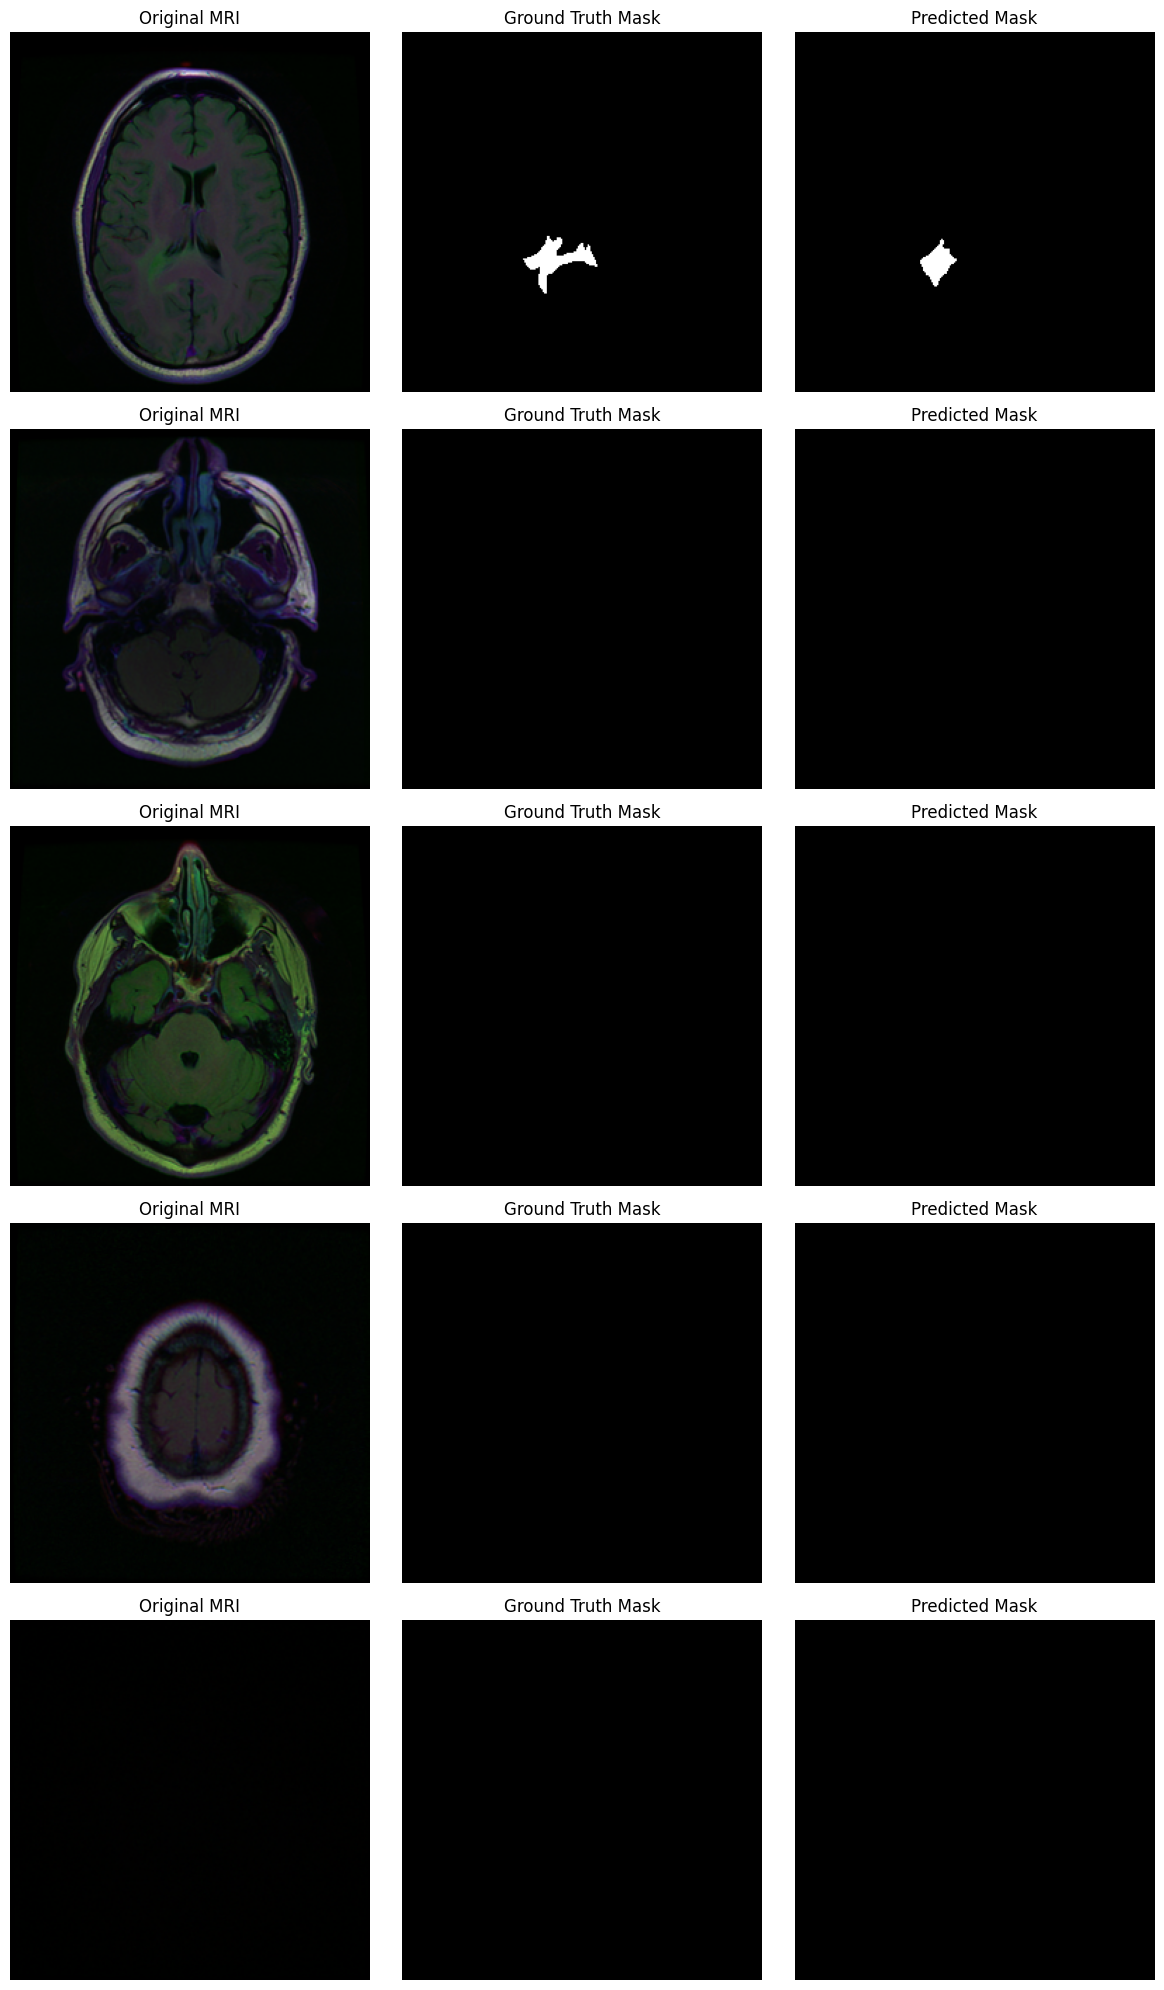

In [52]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# Test loader se ek batch lo
images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    predictions = model(images)
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()

# CPU pe wapis lao aur numpy mein convert karo, visualization ke liye
images = images.cpu().numpy()
masks = masks.cpu().numpy()
predictions = predictions.cpu().numpy()

# 5 examples dikhate hain
num_examples = 5
fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4*num_examples))

for i in range(num_examples):
    # Image ko (C,H,W) se (H,W,C) mein wapis convert karo display ke liye
    img = np.transpose(images[i], (1, 2, 0))
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original MRI")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(masks[i], cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(predictions[i][0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig('/kaggle/working/predictions_visualization.png', dpi=150)
plt.show()

In [53]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# Poore test set se images collect karo jinme tumor hai
tumor_images = []
tumor_masks = []
tumor_predictions = []

with torch.no_grad():
    for images, masks in test_loader:
        images_gpu = images.to(device)
        masks_gpu = masks.to(device)
        
        predictions = model(images_gpu)
        predictions = torch.sigmoid(predictions)
        predictions = (predictions > 0.5).float()
        
        # Check karo kaunsi images mein asal tumor hai (mask sum > 0)
        for i in range(images.shape[0]):
            if masks[i].sum() > 0:  # matlab is mask mein kuch tumor pixels hain
                tumor_images.append(images[i].numpy())
                tumor_masks.append(masks[i].numpy())
                tumor_predictions.append(predictions[i].cpu().numpy())
        
        # Jab humare paas kaafi examples ikattha ho jayen, ruk jao
        if len(tumor_images) >= 8:
            break

print(f"Total tumor-containing examples mile: {len(tumor_images)}")

Total tumor-containing examples mile: 10


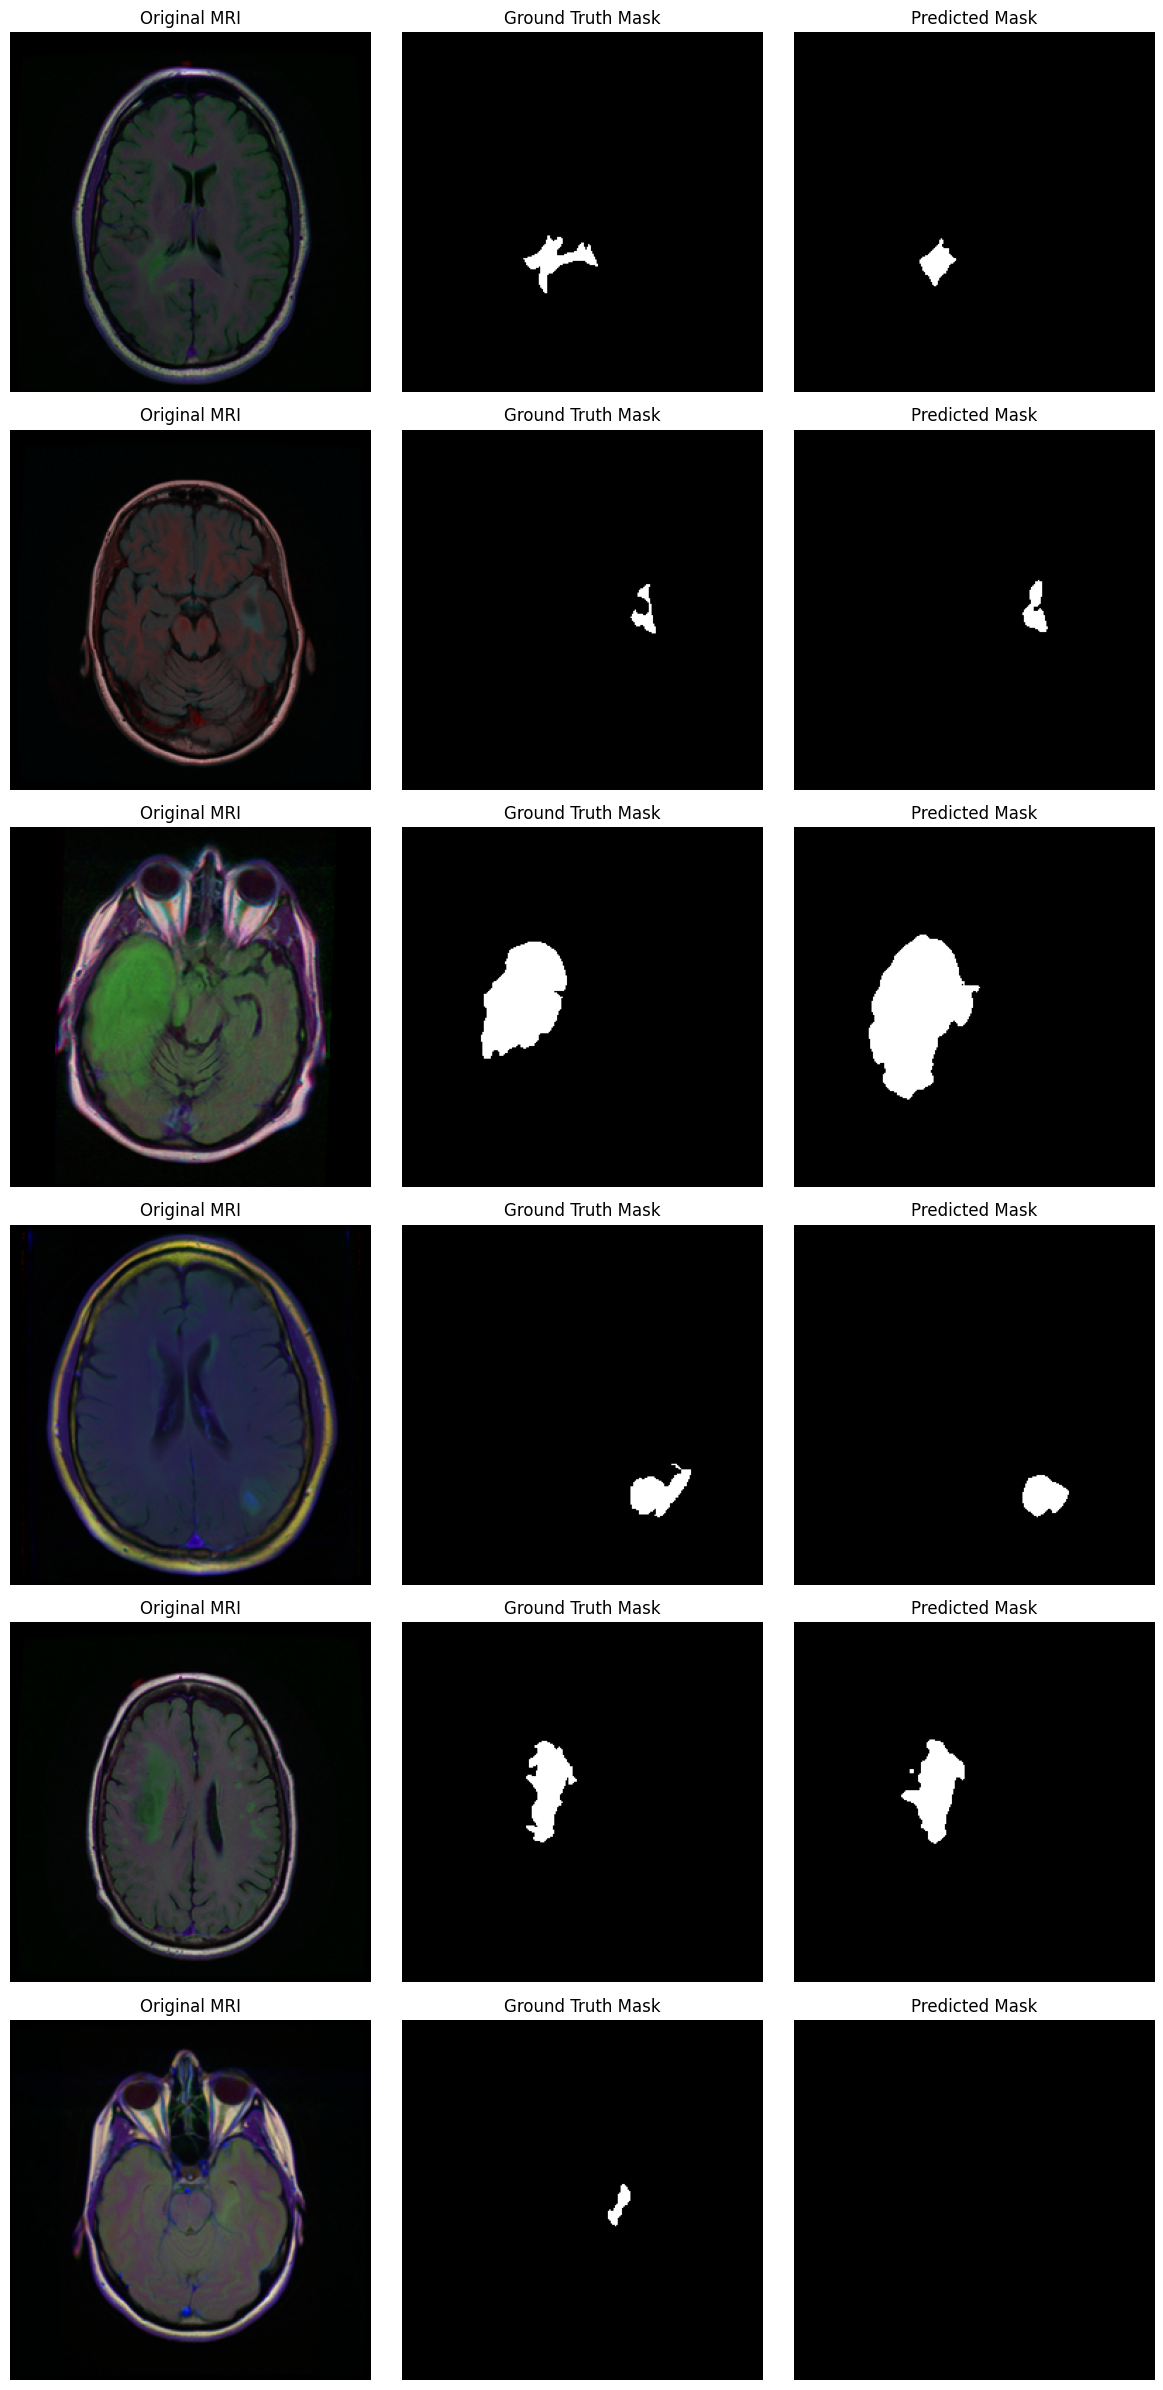

In [55]:
num_examples = min(6, len(tumor_images))
fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4*num_examples))

for i in range(num_examples):
    img = np.transpose(tumor_images[i], (1, 2, 0))
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original MRI")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(tumor_masks[i], cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(tumor_predictions[i][0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig('/kaggle/working/tumor_predictions_visualization.png', dpi=150)
plt.show()

In [ ]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
    
    def forward(self, predictions, targets):
        predictions = torch.sigmoid(predictions)
        
        predictions = predictions.view(-1)
        targets = targets.view(-1)
        
        TP = (predictions * targets).sum()
        FP = ((1 - targets) * predictions).sum()
        FN = (targets * (1 - predictions)).sum()
        
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        
        return 1 - tversky

In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.tversky = TverskyLoss(alpha=0.3, beta=0.7)
    
    def forward(self, predictions, targets):
        bce_loss = self.bce(predictions, targets)
        tversky_loss = self.tversky(predictions, targets)
        return bce_loss + tversky_loss

In [ ]:
# Naya model banao (fresh weights se shuru, taake fair comparison ho purane se)
model = UNet(in_channels=3, out_channels=1)
model = model.to(device)

criterion = CombinedLoss()  # Ab Tversky-based hai
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
model.load_state_dict(
    torch.load('/kaggle/input/your-model-folder/best_unet_model.pth')
)

In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/README.md
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/data.csv
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_52.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_10.tif
/kaggle/input/datasets/ma

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

/kaggle/input/notebooks/fatimaakhan07/updated/best_unet_tversky.pth
/kaggle/input/notebooks/fatimaakhan07/unetsegmentation/best_unet_model.pth


In [2]:
num_examples = min(6, len(tumor_images))
fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4*num_examples))

for i in range(num_examples):
    img = np.transpose(tumor_images[i], (1, 2, 0))
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original MRI")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(tumor_masks[i], cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(tumor_predictions[i][0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig('/kaggle/working/tumor_predictions_visualization.png', dpi=150)
plt.show()

NameError: name 'tumor_images' is not defined

In [51]:
model_path = "/kaggle/input/...../best_unet_tversky.pth"

import os
print(os.path.exists(model_path))
print(os.path.getsize(model_path))

False


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/...../best_unet_tversky.pth'

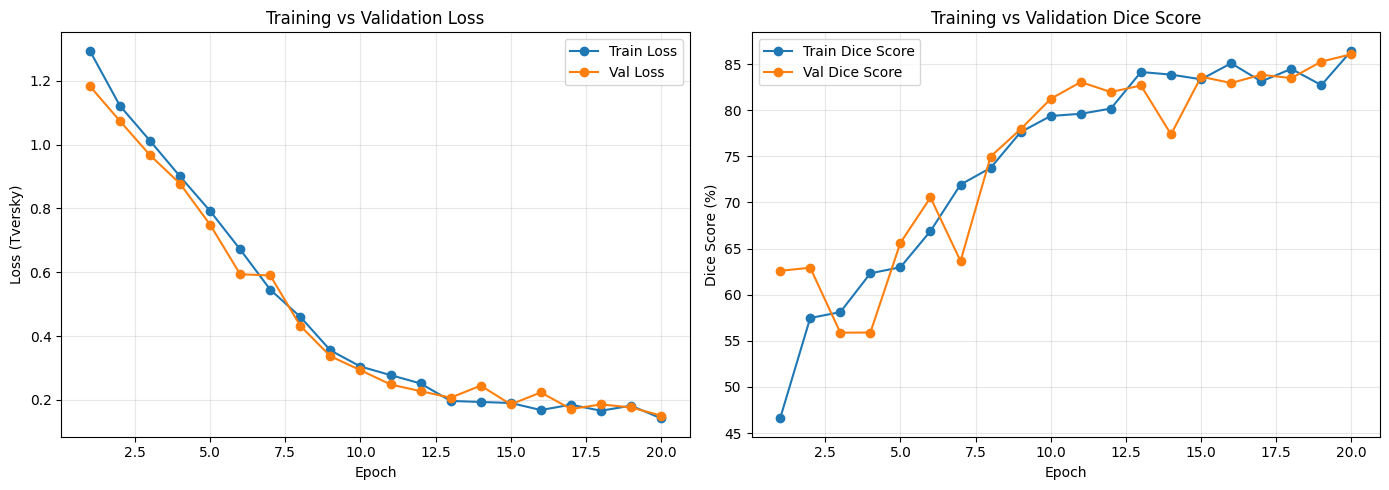

In [58]:
import matplotlib.pyplot as plt

# Aapke training log se liye gaye numbers (agar history variable already exist karta hai to ye skip karo)
train_loss = [1.2942, 1.1217, 1.0122, 0.9003, 0.7920, 0.6716, 0.5456, 0.4604, 0.3554, 
              0.3048, 0.2779, 0.2517, 0.1969, 0.1937, 0.1905, 0.1684, 0.1852, 0.1662, 0.1821, 0.1424]
val_loss = [1.1833, 1.0740, 0.9670, 0.8777, 0.7491, 0.5938, 0.5900, 0.4323, 0.3371, 
            0.2933, 0.2486, 0.2275, 0.2071, 0.2449, 0.1860, 0.2237, 0.1715, 0.1861, 0.1767, 0.1510]

train_acc = [46.60, 57.48, 58.11, 62.32, 62.98, 66.90, 71.94, 73.75, 77.63, 
             79.38, 79.61, 80.18, 84.14, 83.86, 83.35, 85.09, 83.12, 84.48, 82.72, 86.45]
val_acc = [62.59, 62.93, 55.89, 55.90, 65.63, 70.54, 63.64, 74.98, 77.95, 
           81.24, 83.05, 81.97, 82.68, 77.38, 83.63, 82.95, 83.85, 83.48, 85.27, 86.07]

epochs = range(1, 21)  # 1 se 20 tak

# Do graphs ek sath banayenge: Loss aur Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Loss curve
axes[0].plot(epochs, train_loss, label='Train Loss', marker='o')
axes[0].plot(epochs, val_loss, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Tversky)')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2: Accuracy (Dice Score) curve
axes[1].plot(epochs, train_acc, label='Train Dice Score', marker='o')
axes[1].plot(epochs, val_acc, label='Val Dice Score', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score (%)')
axes[1].set_title('Training vs Validation Dice Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')  # Portfolio ke liye save
plt.show()

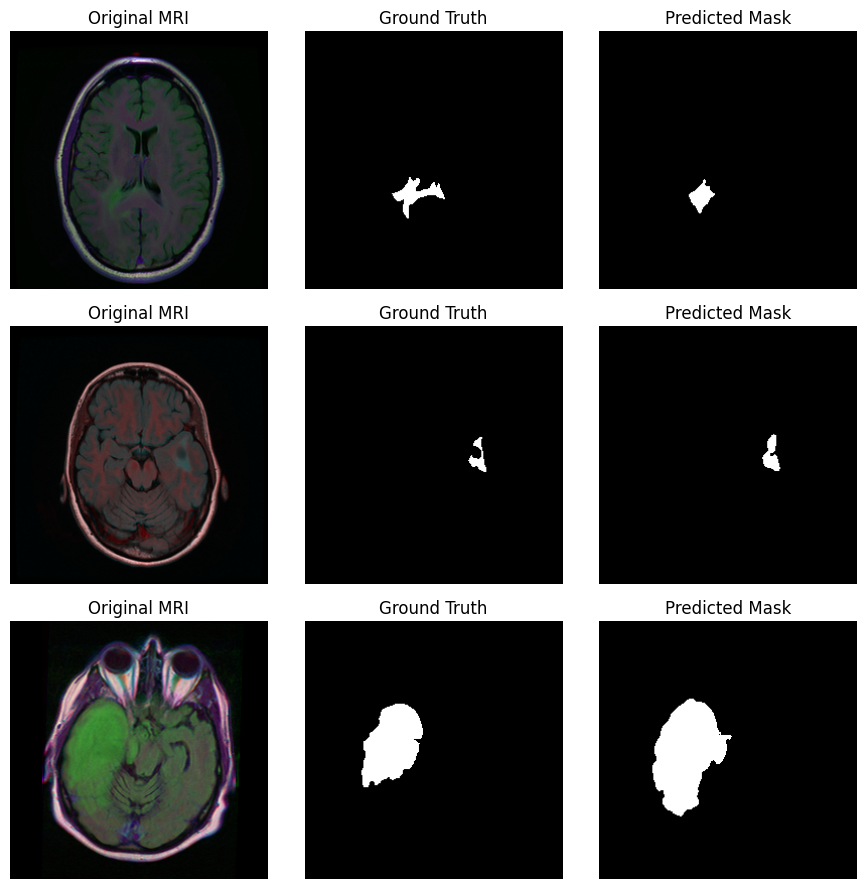

In [59]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
images, masks = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(images_gpu))
    preds = (preds > 0.5).float()

images_cpu = images.cpu().numpy()
masks_cpu = masks.cpu().numpy()
preds_cpu = preds.cpu().numpy()

good_indices = [i for i in range(len(masks_cpu)) if masks_cpu[i].sum() > 50][:5]

fig, axes = plt.subplots(len(good_indices), 3, figsize=(9, 3*len(good_indices)))

for row, idx in enumerate(good_indices):
    img = np.transpose(images_cpu[idx], (1, 2, 0))
    img = (img - img.min()) / (img.max() - img.min())
    axes[row, 0].imshow(img)
    axes[row, 0].set_title('Original MRI')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(masks_cpu[idx].squeeze(), cmap='gray')
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(preds_cpu[idx].squeeze(), cmap='gray')
    axes[row, 2].set_title('Predicted Mask')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('best_predictions_collage.png', dpi=150, bbox_inches='tight')
plt.show()